In [4]:
# ============================================================
# 第1节：安装与导入依赖
# 请根据环境按需安装缺失的库，例如：
# !pip install pandas numpy lightgbm optuna scikit-learn tqdm shap matplotlib
# ============================================================

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
from tqdm.notebook import tqdm
import optuna
from optuna.integration.lightgbm import LightGBMPruningCallback
import shap
import matplotlib.pyplot as plt
import warnings
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['pdf.use14corefonts'] = True
plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.1
plt.rcParams['agg.path.chunksize'] = 0
warnings.filterwarnings('ignore')

In [4]:
# ============================================================
# 第2节：数据加载与预处理
# ============================================================

data_path = 'GDSC_input_data.2.0.csv'
df = pd.read_csv(data_path,index_col=0)

print("数据形状:", df.shape)
df.head()

数据形状: (968, 714)


,SANGER_MODEL_ID,DRUG_Z_score,ACACA_CNV,ADAMTS19_CNV,ADCY2_CNV,AFF2_CNV,AGAP1_CNV,AGBL4_CNV,AKAP6_CNV,AKT3_CNV,...,ZFPM2_indel,BMPR1B_indel,KLHL29_indel,MDH1_indel,NR3C2_indel,TBC1D5_indel,CNTN4_indel,TRAPPC12_indel,CD226_indel,RORA_indel
1,SIDM00003,-0.163038,3.00,3.0,3.0,2.0,3.0,4.0,2.0,3.0,...,0,0,0,0,0,0,0,0,0,0
2,SIDM00023,0.567856,3.04,2.0,6.0,2.0,2.0,3.0,4.0,3.0,...,0,0,0,0,0,0,0,0,0,0
3,SIDM00040,-0.001298,3.00,3.0,5.0,2.0,2.0,2.0,3.0,2.0,...,0,0,0,0,0,0,0,0,0,0
4,SIDM00041,-0.522523,3.00,4.0,4.0,2.0,3.0,4.0,4.0,4.0,...,0,0,0,0,0,0,0,0,0,0
5,SIDM00042,0.135437,5.00,6.0,6.0,2.0,5.0,3.0,6.0,5.0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# 分离特征和标签
# 第一列是 cell_id（字符串），第二列是药物 z-score
cell_ids = df.iloc[:, 0]
y = df.iloc[:, 1].values.astype(float)

feature_cols = df.columns[2:]
X = df[feature_cols]

print("特征数量:", X.shape[1])
print("标签均值:", y.mean(), "标准差:", y.std())

特征数量: 712
标签均值: -0.004974503738816855 标准差: 0.6920999675160332


In [6]:
# 对一些方差低的列先行过滤
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)  
X = pd.DataFrame(selector.fit_transform(X), 
                 columns=feature_cols[selector.get_support()])
print("去除常数特征后特征数:", X.shape[1])

去除常数特征后特征数: 550


In [7]:
# ============================================================
# 第3节：特征初步筛选
# 使用 LightGBM 默认参数训练，基于特征重要性（gain）选取 Top N 个特征
# ============================================================

def select_features_lightgbm(X, y, top_k=500, seed=42):
    """
    用 LightGBM 默认参数快速训练，返回重要性最高的特征名
    """
    lgbm = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        random_state=seed,
        n_jobs=-1,
        verbosity=-1
    )
    lgbm.fit(X, y)
    importance = pd.Series(lgbm.feature_importances_, index=X.columns)
    importance = importance.sort_values(ascending=False)
    top_features = importance.head(top_k).index.tolist()
    print(f"选取前 {top_k} 个重要特征")
    return top_features, importance

N_FEATURES = 500
top_features, full_importance = select_features_lightgbm(X, y, top_k=N_FEATURES)
X_selected = X[top_features]
print("筛选后特征矩阵形状:", X_selected.shape)

选取前 500 个重要特征
筛选后特征矩阵形状: (968, 500)


In [8]:
# ============================================================
# 第4节：Optuna 函数（带交叉验证和早停）
# ============================================================

def objective(trial, X, y, n_folds=5, seed=42):
    """
    Optuna 函数：对给定的超参数组合，执行5折CV，
    返回平均验证 RMSE
    """
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': seed,
        'n_jobs': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    }
    
    early_stop_rounds = 50
    num_boost_round = 1000
    
    cv_scores = []
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    
    X_np = X.values
    y_np = y
    
    for fold_idx, (train_idx, valid_idx) in enumerate(kf.split(X_np)):
        X_train, X_val = X_np[train_idx], X_np[valid_idx]
        y_train, y_val = y_np[train_idx], y_np[valid_idx]
        
        dtrain = lgb.Dataset(X_train, label=y_train)
        dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        
        callbacks = [
            lgb.early_stopping(early_stop_rounds, verbose=False),
            LightGBMPruningCallback(trial, 'rmse', valid_name='valid')
        ]
        
        try:
            model = lgb.train(
                params=param,
                train_set=dtrain,
                num_boost_round=num_boost_round,
                valid_sets=[dtrain, dvalid],
                valid_names=['train', 'valid'],
                callbacks=callbacks
            )
        except optuna.exceptions.TrialPruned:
            raise
        
        y_pred = model.predict(X_val, num_iteration=model.best_iteration)
        fold_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        cv_scores.append(fold_rmse)
        
        trial.report(fold_rmse, step=fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    
    return np.mean(cv_scores)

In [9]:
# ============================================================
# 第5节：启动 Optuna 调参
# ============================================================

N_TRIALS = 100
STUDY_SEED = 42

# 创建 Optuna study，提前停止表现较差的 trial
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5, interval_steps=1),
    sampler=optuna.samplers.TPESampler(seed=STUDY_SEED)
)

# 目标函数闭包绑定数据
obj = lambda trial: objective(trial, X_selected, y, n_folds=5, seed=STUDY_SEED)

# 使用 tqdm 显示整体 trial 进度
progress_bar = tqdm(total=N_TRIALS, desc='Optuna 调参')

def progress_callback(study, trial):
    progress_bar.update(1)

# 开始优化，传入回调更新进度条
study.optimize(
    obj,
    n_trials=N_TRIALS,
    callbacks=[progress_callback],
    show_progress_bar=False  # 关闭内置进度条，使用自定义
)
progress_bar.close()

# 输出最佳参数和内部交叉验证分数
print("\n最佳 RMSE: {:.4f}".format(study.best_value))
print("最佳参数组合：")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-08-28 12:14:56,213] A new study created in memory with name: no-name-74c65096-bd03-427d-b12a-38d4ac20a2f4


Optuna 调参:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-08-28 12:15:28,979] Trial 0 finished with value: 0.6054267092458965 and parameters: {'learning_rate': 0.03574712922600244, 'num_leaves': 244, 'max_depth': 10, 'min_child_samples': 62, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 0.6054267092458965.
[I 2026-08-28 12:16:04,862] Trial 1 finished with value: 0.6140473716909246 and parameters: {'learning_rate': 0.07725378389307355, 'num_leaves': 185, 'max_depth': 3, 'min_child_samples': 98, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 0 with value: 0.6054267092458965.
[I 2026-08-28 12:25:28,325] Trial 2 finished with value: 0.6019842377380894 and parameters: {'learning_rate': 0.028145092716060652, 'num_leaves': 141, 'max_depth': 7, 'min_child_samples': 32, 'subsample': 0.8447411578889518, 'col


最佳 RMSE: 0.5933
最佳参数组合：
  learning_rate: 0.08179248551993995
  num_leaves: 146
  max_depth: 5
  min_child_samples: 21
  subsample: 0.8624559281129569
  colsample_bytree: 0.8873272630652603
  reg_alpha: 7.418097012347051e-05
  reg_lambda: 3.0338918936010646e-08


In [10]:
print("\n最佳 RMSE: {:.4f}".format(study.best_value))
print("最佳参数组合：")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


最佳 RMSE: 0.5933
最佳参数组合：
  learning_rate: 0.08179248551993995
  num_leaves: 146
  max_depth: 5
  min_child_samples: 21
  subsample: 0.8624559281129569
  colsample_bytree: 0.8873272630652603
  reg_alpha: 7.418097012347051e-05
  reg_lambda: 3.0338918936010646e-08


In [11]:
# ============================================================
# 第6节：使用最佳参数进行全数据 5 折交叉验证评估模型可靠性
# 这里采用纯交叉验证策略：不单独划分测试集，直接用全部数据做5折CV
# 记录每折的指标：MAE, MSE, MAPE, Pearson r
# ============================================================

best_params = study.best_params
# 去除 Optuna 添加的可能不适用的参数（若存在），保留 lightgbm 可接收的
train_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': STUDY_SEED,
    'n_jobs': -1,
    'verbosity': -1,
    'learning_rate': best_params['learning_rate'],
    'num_leaves': best_params['num_leaves'],
    'max_depth': best_params['max_depth'],
    'min_child_samples': best_params['min_child_samples'],
    'subsample': best_params['subsample'],
    'colsample_bytree': best_params['colsample_bytree'],
    'reg_alpha': best_params['reg_alpha'],
    'reg_lambda': best_params['reg_lambda']
}

# 5折交叉验证
kf_eval = KFold(n_splits=5, shuffle=True, random_state=STUDY_SEED)
y_true_all = []
y_pred_all = []
models = []  # 保留每折模型用于可能的分析

X_arr = X_selected.values
y_arr = y

for train_idx, valid_idx in kf_eval.split(X_arr):
    X_train, X_val = X_arr[train_idx], X_arr[valid_idx]
    y_train, y_val = y_arr[train_idx], y_arr[valid_idx]
    
    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    
    model = lgb.train(
        params=train_params,
        train_set=dtrain,
        num_boost_round=500,  # 可适当调整，也可以使用 early_stopping
        valid_sets=[dtrain, dvalid],
        valid_names=['train', 'valid'],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    y_pred = model.predict(X_val, num_iteration=model.best_iteration)
    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred)
    models.append(model)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# 计算各项指标
mae = mean_absolute_error(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
# MAPE 注意避免除零，加入微小值
mask = np.abs(y_true_all) > 1e-6
mape = np.mean(np.abs((y_true_all[mask] - y_pred_all[mask]) / y_true_all[mask])) * 100
pearson_corr, pearson_p = pearsonr(y_true_all, y_pred_all)

print("========== 模型可靠性评估 ==========")
print(f"MAE       : {mae:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"MAPE      : {mape:.2f}%")
print(f"Pearson r : {pearson_corr:.4f} (p-value={pearson_p:.2e})")

========== 模型可靠性评估 ==========
MAE       : 0.4717
MSE       : 0.3533
RMSE      : 0.5944
MAPE      : 287.96%
Pearson r : 0.5125 (p-value=6.04e-66)


In [12]:
# ============================================================
# 第7节：全数据训练 → SHAP 解释 → 模型内置重要性 Top 20
# ============================================================

# 使用早停阶段得到的 best_iter（来自之前划分的验证集，如无请重新执行以下计算）
# 如果 best_iter 未定义，则重新获得（例如使用第7节原划分，或直接设定一个默认值）
if 'best_iter' not in dir():
    # 若未执行过划分，则先临时划分计算 best_iter
    X_temp, X_val_temp, y_temp, y_val_temp = train_test_split(
        X_arr, y_arr, test_size=0.2, random_state=STUDY_SEED)
    dtrain_temp = lgb.Dataset(X_temp, label=y_temp)
    dvalid_temp = lgb.Dataset(X_val_temp, label=y_val_temp, reference=dtrain_temp)
    model_temp = lgb.train(
        params=train_params,
        train_set=dtrain_temp,
        num_boost_round=1000,
        valid_sets=[dtrain_temp, dvalid_temp],
        valid_names=['train', 'valid'],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    best_iter = model_temp.best_iteration
    print(f"获得最佳迭代数: {best_iter}")
else:
    print(f"使用已有 best_iter: {best_iter}")

# 全数据训练（无需验证集）
dtrain_all = lgb.Dataset(X_arr, label=y_arr)
final_model = lgb.train(
    params=train_params,
    train_set=dtrain_all,
    num_boost_round=best_iter,   # 固定迭代数
)

获得最佳迭代数: 102


In [13]:
# ---------- SHAP 解释 ----------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_arr)

# 全局 SHAP 汇总图
shap.summary_plot(shap_values, X_arr, feature_names=X_selected.columns, max_display=10, show=False)
fig = plt.gcf()
fig.savefig("/mnt/NC/LJW/MiDAS_score/input/LightGBM2.0/SHAP.pdf", format='pdf',dpi = 300, bbox_inches='tight')
plt.close(fig)

模型特征重要性 (gain) Top 20:
    feature       gain
   FAT3_CNV 120.839464
   CDH4_CNV 115.450663
  WDR70_CNV  59.342970
 ATP8A2_CNV  57.364506
  AKAP6_CNV  46.157307
  PTPRD_CNV  45.512112
 LINGO2_CNV  44.805332
    DCC_CNV  39.964810
  MCTP1_SNP  33.195240
   MSRA_CNV  30.740440
 CEP85L_CNV  28.925226
TRAPPC9_CNV  26.123487
   BBS9_CNV  24.920653
   KAZN_CNV  24.789876
SLC44A5_CNV  23.998892
   ULK4_CNV  22.860210
 CDKAL1_CNV  22.093819
  CSMD3_SNP  20.853898
 IMMP2L_SNP  20.785058
  MECOM_CNV  20.188906


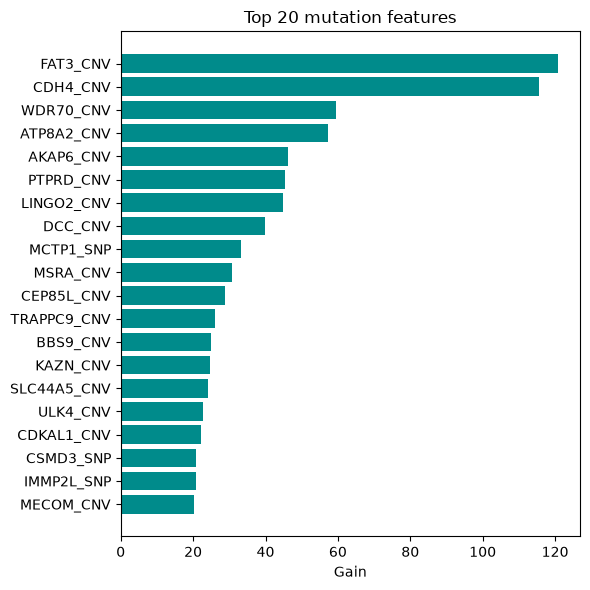

In [53]:
# ---------- 模型内置重要性（gain）Top 20 特征 ----------
importance_gain = final_model.feature_importance(importance_type='gain')
gain_df = pd.DataFrame({
    'feature': X_selected.columns,
    'gain': importance_gain
}).sort_values('gain', ascending=False)

top20_gain = gain_df.head(20)
print("模型特征重要性 (gain) Top 20:")
print(top20_gain.to_string(index=False))

# 绘制条形图
plt.figure(figsize=(6, 6))
plt.barh(top20_gain['feature'], top20_gain['gain'], color='darkcyan')
plt.xlabel('Gain')
plt.title('Top 20 mutation features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("/mnt/NC/LJW/MiDAS_score/input/LightGBM2.0/Important_mutant_pattern2.pdf", format='pdf', bbox_inches='tight')
plt.show()

Top 20 特征与 IC50 z-score 的 Spearman 相关系数:
    feature  spearman_r      p_value       gain
 LINGO2_CNV    0.005502 8.642443e-01  44.805332
  PTPRD_CNV   -0.014299 6.568043e-01  45.512112
    DCC_CNV   -0.022823 4.781675e-01  39.964810
   MSRA_CNV   -0.031227 3.317739e-01  30.740440
  MCTP1_SNP    0.038372 2.329637e-01  33.195240
  CSMD3_SNP    0.060730 5.892266e-02  20.853898
 ATP8A2_CNV    0.088774 5.711492e-03  57.364506
 CEP85L_CNV    0.090293 4.933085e-03  28.925226
   ULK4_CNV    0.095049 3.075192e-03  22.860210
 IMMP2L_SNP    0.103692 1.234964e-03  20.785058
   KAZN_CNV    0.119313 1.986977e-04  24.789876
SLC44A5_CNV    0.137254 1.826359e-05  23.998892
 CDKAL1_CNV    0.223752 1.895045e-12  22.093819
TRAPPC9_CNV    0.230512 3.853965e-13  26.123487
  MECOM_CNV    0.249200 3.611463e-15  20.188906
  AKAP6_CNV    0.254391 9.195316e-16  46.157307
   FAT3_CNV    0.260205 1.913883e-16 120.839464
   BBS9_CNV    0.264316 6.160169e-17  24.920653
  WDR70_CNV    0.271425 8.273232e-18  59.342970

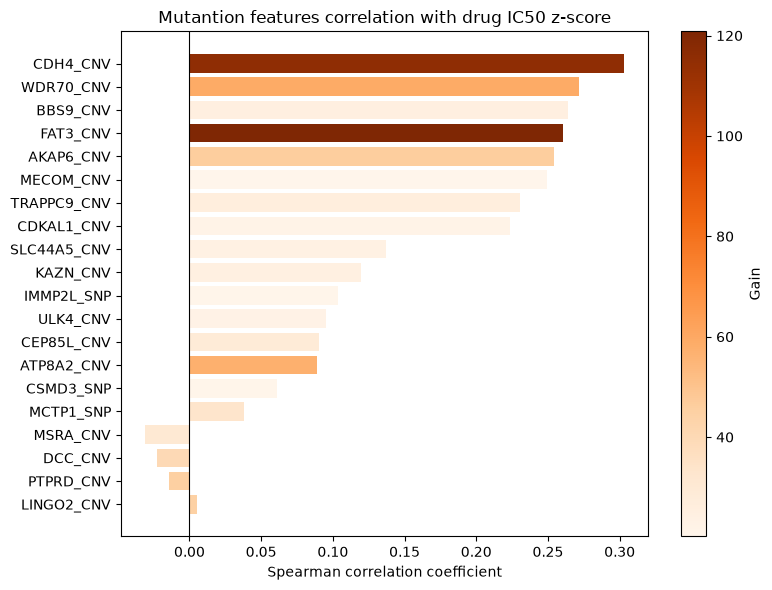

In [51]:
# ============================================================
# 第8节：柱状图长度=Spearman r，颜色=Gain（plasma 渐变）
# ============================================================

from scipy.stats import spearmanr
import matplotlib.cm as cm

top20_features = top20_gain['feature'].tolist()
gain_dict = dict(zip(top20_gain['feature'], top20_gain['gain']))

spearman_r_list = []
p_values = []
gain_values = []

for feat in top20_features:
    r, p = spearmanr(X_selected[feat], y)
    spearman_r_list.append(r)
    p_values.append(p)
    gain_values.append(gain_dict[feat])

spearman_summary = pd.DataFrame({
    'feature': top20_features,
    'spearman_r': spearman_r_list,
    'p_value': p_values,
    'gain': gain_values
}).sort_values('spearman_r', key=abs, ascending=True)

print("Top 20 特征与 IC50 z-score 的 Spearman 相关系数:")
print(spearman_summary.to_string(index=False))

# 颜色映射：gain 值归一化，使用 plasma 色带
gain_norm = plt.Normalize(vmin=spearman_summary['gain'].min(), 
                          vmax=spearman_summary['gain'].max())
colors = cm.Oranges(gain_norm(spearman_summary['gain'].values))

plt.figure(figsize=(8, 6))
bars = plt.barh(spearman_summary['feature'], spearman_summary['spearman_r'], color=colors)
plt.xlabel("Spearman correlation coefficient")
plt.title('Mutantion features correlation with drug IC50 z-score')
plt.axvline(0, color='black', linewidth=0.8)

# 添加颜色条
sm = plt.cm.ScalarMappable(cmap='Oranges', norm=gain_norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Gain')

plt.tight_layout()
plt.savefig("/mnt/NC/LJW/MiDAS_score/input/LightGBM2.0/Important_mutant_pattern.pdf", format='pdf', bbox_inches='tight')
plt.show()

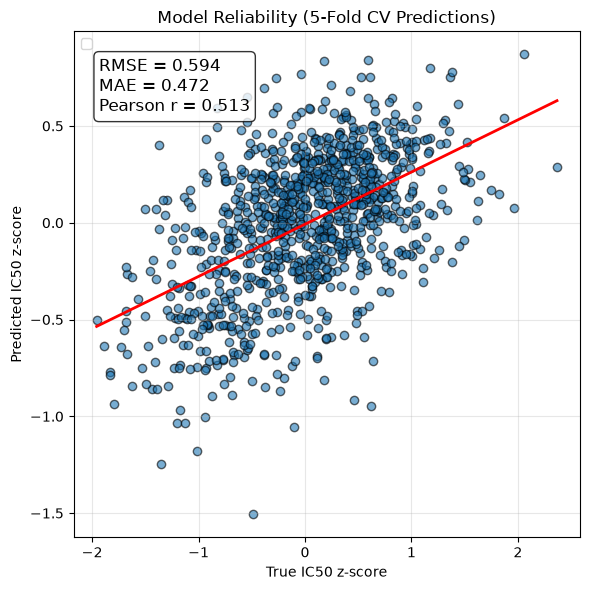

In [54]:
# ============================================================
# 第9节（修改）：模型可靠性散点图（线性回归拟合线）
# ============================================================

from scipy.stats import linregress

if 'y_true_all' not in dir() or 'y_pred_all' not in dir():
    raise RuntimeError("请先运行第6节交叉验证以获得 y_true_all 和 y_pred_all")

# 线性回归拟合
slope, intercept, r_value, p_value_reg, std_err = linregress(y_true_all, y_pred_all)
r2 = r_value**2

# 计算其他指标
rmse_val = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
mae_val = mean_absolute_error(y_true_all, y_pred_all)
pearson_corr, pearson_p = pearsonr(y_true_all, y_pred_all)

# 绘图
plt.figure(figsize=(6, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.6, edgecolor='k')

# 绘制回归线
x_range = np.linspace(y_true_all.min(), y_true_all.max(), 100)
plt.plot(x_range, slope * x_range + intercept, 'r-', lw=2)

plt.xlabel('True IC50 z-score')
plt.ylabel('Predicted IC50 z-score')
plt.title('Model Reliability (5-Fold CV Predictions)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

# 指标文本
text_str = (f'RMSE = {rmse_val:.3f}\nMAE = {mae_val:.3f}\n'
            f'Pearson r = {pearson_corr:.3f}')
plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("/mnt/NC/LJW/MiDAS_score/input/LightGBM2.0/Model_reliability.pdf", format='pdf', bbox_inches='tight')
plt.show()

findfont: Failed to find font weight normal, now using medium.
findfont: Failed to find font weight normal, now using medium.
findfont: Failed to find font weight normal, now using medium.
findfont: Failed to find font weight normal, now using medium.


二分类阈值（中位数 z-score）: 0.0268
ROC AUC: 0.7215


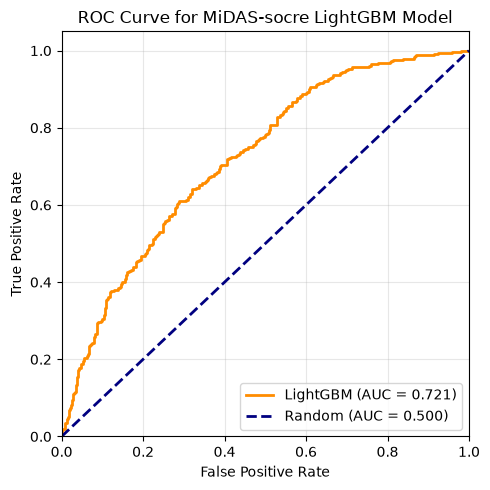

In [5]:
# ============================================================
# 第12节：基于 AUC 评估模型可靠性（回归转二分类）
# ============================================================

from sklearn.metrics import roc_auc_score, roc_curve

# 1. 将连续标签二值化（例如大于中位数定为“敏感”，小于等于“耐药”）
threshold = np.median(y_true_all)
y_binary = (y_true_all > threshold).astype(int)
print(f"二分类阈值（中位数 z-score）: {threshold:.4f}")

# 2. 使用交叉验证的预测值作为“敏感性得分”
#    预测值越高 → 越倾向敏感类
y_score = y_pred_all

# 3. 计算 AUC
auc = roc_auc_score(y_binary, y_score)
print(f"ROC AUC: {auc:.4f}")

# 4. 绘制 ROC 曲线
fpr, tpr, thresholds = roc_curve(y_binary, y_score)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LightGBM (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label=f'Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for MiDAS-socre LightGBM Model')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/mnt/NC/LJW/MiDAS_score/input/LightGBM2.0/roc_curve_auc.pdf", format='pdf', bbox_inches='tight')
plt.show()

正在进行 t-SNE 降维...


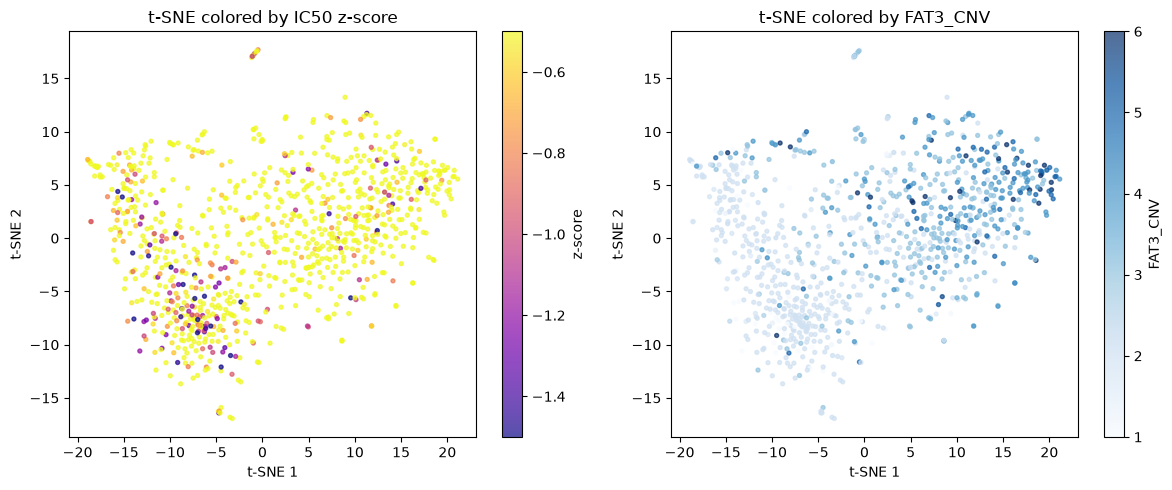

In [82]:
# ============================================================
# 第13节：t-SNE 降维可视化（颜色对应 z-score 或指定突变特征）
# ============================================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

# 自定义渐变色：高值 -> #D73221，低值 -> #E48070（注意顺序：高值深红，低值浅红）
custom_cmap = LinearSegmentedColormap.from_list(
    'my_blues', ['#FFFFFF', '#FCB777'], N=256
)

# 数据准备
X_plot = X               # 全特征矩阵（已筛选）
zscore = y               # IC50 z-score

# 指定要着色的突变特征（例：FAT_CNV；若不存在则自动替换为第一个特征）
feature_name = 'FAT3_CNV'
mut_values = X_selected[feature_name].values

# ---------- t-SNE 降维 ----------
print("正在进行 t-SNE 降维...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
embedding_tsne = tsne.fit_transform(X_plot)

# ---------- 绘图（两个子图）----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：按 z-score 着色
sc1 = axes[0].scatter(embedding_tsne[:, 0], embedding_tsne[:, 1],
                      c=zscore, cmap='plasma', s=8, alpha=0.7, vmin = -1.5 , vmax = -0.5)
axes[0].set_title('t-SNE colored by IC50 z-score')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
fig.colorbar(sc1, ax=axes[0], label='z-score')

# 右图：按突变特征着色
sc2 = axes[1].scatter(embedding_tsne[:, 0], embedding_tsne[:, 1],
                      c=mut_values, cmap='Blues', s=8, alpha=0.7, vmin = 1 , vmax = 6)
axes[1].set_title(f't-SNE colored by {feature_name}')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
fig.colorbar(sc2, ax=axes[1], label=feature_name)

plt.tight_layout()
plt.savefig('/mnt/NC/LJW/MiDAS_score/input/LightGBM2.0/Umap_tSNE.pdf', format='pdf', bbox_inches='tight')
plt.show()

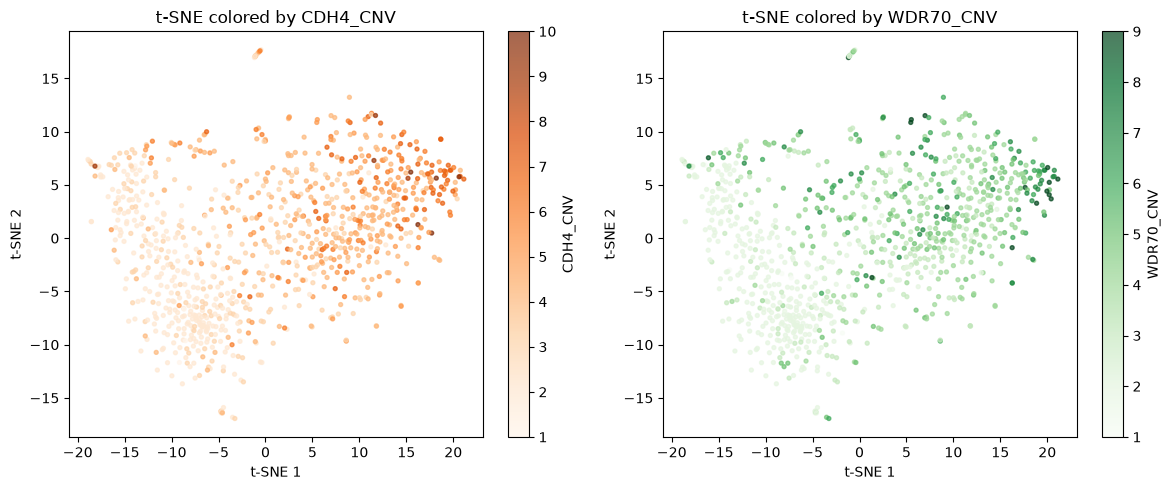

In [8]:
# ---------- 绘图（两个子图）----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：按 z-score 着色
sc1 = axes[0].scatter(embedding_tsne[:, 0], embedding_tsne[:, 1],
                      c=X_selected['CDH4_CNV'].values, cmap='Oranges', 
                      s=8, alpha=0.7, vmin = 1 , vmax = 10)
axes[0].set_title('t-SNE colored by CDH4_CNV')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
fig.colorbar(sc1, ax=axes[0], label='CDH4_CNV')

# 右图：按突变特征着色
sc2 = axes[1].scatter(embedding_tsne[:, 0], embedding_tsne[:, 1],
                      c= X_selected['WDR70_CNV'].values, cmap='Greens', 
                      s=8, alpha=0.7, vmin = 1 , vmax = 9)
axes[1].set_title('t-SNE colored by WDR70_CNV')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
fig.colorbar(sc2, ax=axes[1], label='WDR70_CNV')

plt.tight_layout()
plt.savefig('/mnt/NC/LJW/MiDAS_score/input/LightGBM2.0/Umap_tSNE2.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [20]:
# ============================================================
# 第10节：保存最终模型
# ============================================================

# 将全数据训练的最终模型保存为文件
model_path = 'MiDAS_score_model.LightGBM2.0.lgb'  # 可自定义路径和文件名
final_model.save_model(model_path)
print(f"最终模型已保存至: {model_path}")

# 加载示例（注释，实际使用时取消注释）
# loaded_model = lgb.Booster(model_file='final_drug_sensitivity_model.lgb')

最终模型已保存至: MiDAS_score_model.LightGBM2.0.lgb


In [36]:
# ============================================================
# 第11节：保存所有 Python 对象便于后续分析
# ============================================================

import joblib

# 整理需要保存的对象字典
objects_to_save = {
    # 原始数据特征（列名）
    'top_features': top_features,                     # 筛选后的特征名列表
    # 训练参数与最佳迭代数
    'train_params': train_params,
    'best_iter': best_iter,
    # 模型
    'final_model': final_model,                       # 全数据训练模型（Booster）
    # SHAP 解释器与值（注意：SHAP 值可能很大，如果磁盘空间有限可只保留解释器）
    'explainer': explainer,
    'shap_values': shap_values,
    # 评估指标（5折交叉验证结果）
    'y_true_all': y_true_all,
    'y_pred_all': y_pred_all,
    'mae': mae,
    'mse': mse,
    'rmse': rmse,
    'mape': mape,
    'pearson_corr': pearson_corr,
    'pearson_p': pearson_p,
    # Top20 特征分析结果
    'spearman_summary': spearman_summary,   # 第8节 Spearman 相关系数表格
    'top20_gain': top20_gain,             # 模型内置 gain 重要性 Top20
    # 其他可能需要的对象可根据实际变量名添加
    'X_arr' : X_arr,
    'y_arr' : y_arr,
    'X_selected' : X_selected,
    'y' : y,
    'X' : X,
    'study' : study,
}

# 保存为单个压缩文件（使用 joblib，支持大数组）
output_file = 'model_save.LightGBM2.0.joblib'
joblib.dump(objects_to_save, output_file, compress=('lz4', 3))  # 若未安装 lz4 可改用 'zlib'
print(f"所有对象已保存至: {output_file}")

所有对象已保存至: model_save.LightGBM2.0.joblib


In [3]:
# ======== 重新加载示例（实际使用时取消注释） ========
import joblib
loaded = joblib.load('model_save.LightGBM2.0.joblib')
top_features = loaded['top_features']
train_params = loaded['train_params']
best_iter = loaded['best_iter']
final_model = loaded['final_model']
best_iter = loaded['best_iter']
explainer = loaded['explainer']
shap_values = loaded['shap_values']
y_true_all = loaded['y_true_all']
y_pred_all = loaded['y_pred_all']
mae = loaded['mae']
mse = loaded['mse']
rmse = loaded['rmse']
mape = loaded['mape']
pearson_corr = loaded['pearson_corr']
pearson_p = loaded['pearson_p']
spearman_summary = loaded['spearman_summary']
top20_gain = loaded['top20_gain']
X_arr = loaded['X_arr']
y_arr = loaded['y_arr']
X_selected = loaded['X_selected']
y = loaded['y']
X = loaded['X']
study = loaded['study']
print("对象加载成功")

对象加载成功


In [57]:
# ============================================================
# 第14节：使用 CCLE 外部数据验证模型预测效果（仅含 CNV 特征）
# ============================================================

# 请修改为实际的 CCLE 文件路径
ccle_path = 'test_CCLE.csv'   # 第一列 cell_id，第二列 IC50_zscore，后面是 CNV 特征（gene_CNV 格式）

# 读取数据
ccle_df = pd.read_csv(ccle_path,index_col=0)
print("CCLE 数据形状:", ccle_df.shape)
ccle_df.head()

CCLE 数据形状: (512, 248)


,depMapID,DRUG_Z_score,MAD1L1_CNV,PHTF2_CNV,MDH1_CNV,NRXN3_CNV,CNTLN_CNV,ARHGAP6_CNV,HDAC9_CNV,SNX29_CNV,...,LAMA2_CNV,COL4A6_CNV,CHSY3_CNV,LRBA_CNV,RYR2_CNV,MBD5_CNV,DOK6_CNV,LYRM4_CNV,NSUN6_CNV,ACACA_CNV
1,ACH-000001,0.340546,1.759692,1.889042,1.942106,2.411589,2.373651,1.264354,1.813920,1.308069,...,1.841971,1.869114,1.810442,2.135156,2.236821,1.870199,0.656056,1.842525,1.278180,1.309354
2,ACH-000004,-0.862147,1.602775,1.610814,2.504145,1.450330,6.705710,0.857293,1.432777,1.529439,...,2.268098,0.812247,1.520941,1.538343,2.140507,2.260903,2.224663,1.535719,2.131051,2.301740
3,ACH-000007,-0.110945,2.776076,2.757015,1.955764,1.959152,2.636959,1.072553,2.845478,1.901070,...,2.001344,1.035601,2.775424,2.195041,2.694813,1.908145,1.896811,1.922978,1.944629,1.900510
4,ACH-000008,-0.214699,2.905378,3.029610,2.415057,1.655623,1.652753,1.707076,3.132686,1.600239,...,1.632910,1.677640,1.630506,1.760683,2.281118,2.244778,1.620962,2.348081,1.640171,1.986498
5,ACH-000009,0.669621,2.089524,2.019807,2.487027,1.652587,1.079599,1.228566,1.974947,1.810099,...,2.021436,1.231337,2.086967,1.766721,1.949374,2.408363,1.087705,2.055244,2.812517,2.209920


In [58]:
# 分离 cell_id、真实标签和特征
cell_ids_ccle = ccle_df.iloc[:, 0]
y_ccle_true = ccle_df.iloc[:, 1].values.astype(float)
X_ccle_raw = ccle_df.iloc[:, 2:]

# 统一特征列格式（确保 CNV 后缀与训练时一致，通常为 _CNV）
# 如原始列名为 Gene_CNV 则无需改动；若为其他格式，可统一修改：
# X_ccle_raw.columns = [col.replace(...) for col in X_ccle_raw.columns]

print("CCLE 原始特征数:", X_ccle_raw.shape[1])

CCLE 原始特征数: 246


In [59]:
# 特征对齐：选取与训练模型中使用的特征（top_features）交集
# 注意 CCLE 只有 CNV 特征，因此只能保留交集中的 CNV 列；其他列填0（缺失）
common_features = list(set(top_features) & set(X_ccle_raw.columns))
print(f"与训练集特征的交集数量: {len(common_features)}")

# 创建与训练集完全一致顺序的空 DataFrame，初始化为0
X_ccle_aligned = pd.DataFrame(0, index=np.arange(len(X_ccle_raw)), columns=top_features)

# 将 CCLE 中存在的列填入
for col in common_features:
    X_ccle_aligned[col] = X_ccle_raw[col].values

# 确认对齐后形状
print("对齐后特征矩阵形状:", X_ccle_aligned.shape)

与训练集特征的交集数量: 237
对齐后特征矩阵形状: (512, 500)


In [60]:
# 使用最终模型进行预测
# final_model 为第7节在全数据上训练的 LightGBM Booster
y_ccle_pred = final_model.predict(X_ccle_aligned.values)

# 计算评估指标
mae_ccle = mean_absolute_error(y_ccle_true, y_ccle_pred)
mse_ccle = mean_squared_error(y_ccle_true, y_ccle_pred)
rmse_ccle = np.sqrt(mse_ccle)
# MAPE 避免除零
mask_ccle = np.abs(y_ccle_true) > 1e-6
mape_ccle = np.mean(np.abs((y_ccle_true[mask_ccle] - y_ccle_pred[mask_ccle]) / y_ccle_true[mask_ccle])) * 100
pearson_ccle, p_ccle = pearsonr(y_ccle_true, y_ccle_pred)
r2_ccle = r2_score(y_ccle_true, y_ccle_pred)

print("========== CCLE 验证集性能 ==========")
print(f"MAE       : {mae_ccle:.4f}")
print(f"MSE       : {mse_ccle:.4f}")
print(f"RMSE      : {rmse_ccle:.4f}")
print(f"MAPE      : {mape_ccle:.2f}%")
print(f"Pearson r : {pearson_ccle:.4f} (p-value={p_ccle:.2e})")
print(f"R²        : {r2_ccle:.4f}")

========== CCLE 验证集性能 ==========
MAE       : 0.5427
MSE       : 0.4587
RMSE      : 0.6773
MAPE      : 223.77%
Pearson r : 0.4462 (p-value=2.03e-26)
R²        : 0.0840


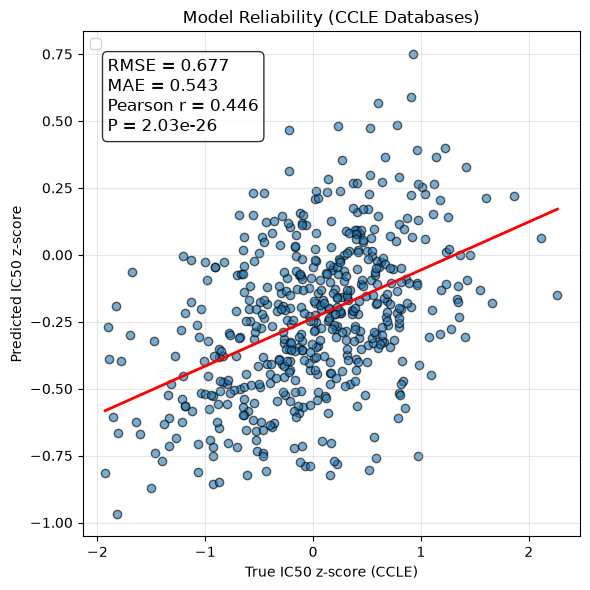

In [62]:
from scipy.stats import linregress

# 线性回归拟合
slope_ccle, intercept_ccle, r_value_ccle, p_value_reg_ccle, _ = linregress(y_ccle_true, y_ccle_pred)
r2_reg_ccle = r_value_ccle ** 2

# 绘图
plt.figure(figsize=(6, 6))
plt.scatter(y_ccle_true, y_ccle_pred, alpha=0.6, edgecolor='k')

# 绘制回归线
x_range_ccle = np.linspace(y_ccle_true.min(), y_ccle_true.max(), 100)
plt.plot(x_range_ccle, slope_ccle * x_range_ccle + intercept_ccle, 'r-', lw=2)

plt.xlabel('True IC50 z-score (CCLE)')
plt.ylabel('Predicted IC50 z-score')
plt.title('Model Reliability (CCLE Databases)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

# 指标文本（保留原有评估指标）
text_str = (f'RMSE = {rmse_ccle:.3f}\nMAE = {mae_ccle:.3f}\nPearson r = {pearson_ccle:.3f}\nP = {p_ccle:.2e}')
plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('/mnt/NC/LJW/MiDAS_score/input/LightGBM2.0/ccle_validation_regression.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [27]:
# ============================================================
# 第15节（修正）：CNV 中介效应分析（仅保留有表达数据的细胞）
# ============================================================
import statsmodels.api as sm
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# 1. ----------------- 加载表达矩阵 -----------------
expr_path = 'GDSC_TPM_input_data.csv'  # 请修改为实际路径
df_expr = pd.read_csv(expr_path,index_col = 0)
print("原始表达数据形状:", df_expr.shape)

# 确保第一列是细胞ID
cell_id_col = df_expr.columns[0]
df_expr.rename(columns={cell_id_col: 'cell_id'}, inplace=True)

原始表达数据形状: (944, 247)


In [28]:
# 2. ----------------- 获取训练时的细胞 ID -----------------
# 必须提供与 y 顺序一致的细胞 ID 列表（没有表达数据的细胞会被自动过滤）
# 如果前面章节没有保存 cell_ids，请在此处读取原始突变数据
# 假设原始突变数据为 "mutation_data.csv"，第一列为细胞ID
cell_ids = pd.read_csv('GDSC_input_data.2.0.csv', usecols=[1]).values.flatten()
# 如果已有变量 cell_ids，直接使用
try:
    cell_ids = cell_ids
except NameError:
    print("请提供细胞ID列表（变量名 cell_ids），或在代码中读取。")
    raise

print(f"训练集总细胞数: {len(cell_ids)}")

# 3. ----------------- 提取 Top CNV 特征 -----------------
cnv_features = [col for col in top20_gain['feature'] if col.endswith('_CNV')]
if len(cnv_features) == 0:
    cnv_features = [col for col in X_selected.columns if col.endswith('_CNV')][:10]
    print("Top20 中无 CNV 特征，自动提取前10个 CNV 特征。")
else:
    print(f"将分析以下 CNV 特征（最多20个）: {cnv_features[:20]}")
cnv_features = cnv_features[:20]
genes = [feat.replace('_CNV', '') for feat in cnv_features]

训练集总细胞数: 968
将分析以下 CNV 特征（最多20个）: ['FAT3_CNV', 'CDH4_CNV', 'WDR70_CNV', 'ATP8A2_CNV', 'AKAP6_CNV', 'PTPRD_CNV', 'LINGO2_CNV', 'DCC_CNV', 'MSRA_CNV', 'CEP85L_CNV', 'TRAPPC9_CNV', 'BBS9_CNV', 'KAZN_CNV', 'SLC44A5_CNV', 'ULK4_CNV', 'CDKAL1_CNV', 'MECOM_CNV']


In [29]:
# 4. ----------------- 构建分析 DataFrame（仅交集细胞）-----------------
df_analysis = pd.DataFrame({'cell_id': cell_ids, 'IC50_zscore': y})
df_cnv = X_selected[cnv_features].copy()
df_analysis = pd.concat([df_analysis, df_cnv], axis=1)

# 表达矩阵只取需要的基因列（注意只保留交集细胞）
expr_genes = [g for g in genes if g in df_expr.columns]
if len(expr_genes) < len(genes):
    missing = set(genes) - set(expr_genes)
    print(f"警告：表达矩阵中缺少基因: {missing}，这些基因将被跳过。")
    genes = expr_genes
    cnv_features = [f for f, g in zip(cnv_features, [feat.replace('_CNV','') for feat in cnv_features]) if g in expr_genes]

df_expr_sub = df_expr[['cell_id'] + genes].copy()

# 内连接，仅保留有表达数据的细胞
df_analysis = df_analysis.merge(df_expr_sub, on='cell_id', how='inner')
print(f"有表达数据的细胞数: {df_analysis.shape[0]} （原始训练集: {len(cell_ids)}，丢失 {len(cell_ids)-df_analysis.shape[0]} 个细胞）")

有表达数据的细胞数: 944 （原始训练集: 968，丢失 24 个细胞）


In [15]:
# 5. ----------------- 中介效应函数（同前）-----------------
def mediation_analysis(data, x_var, m_var, y_var):
    X_total = sm.add_constant(data[x_var])
    model_total = sm.OLS(data[y_var], X_total).fit()
    c = model_total.params[x_var]
    p_c = model_total.pvalues[x_var]
    
    X_a = sm.add_constant(data[x_var])
    model_a = sm.OLS(data[m_var], X_a).fit()
    a = model_a.params[x_var]
    sa = model_a.bse[x_var]
    
    X_b = sm.add_constant(data[[x_var, m_var]])
    model_b = sm.OLS(data[y_var], X_b).fit()
    b = model_b.params[m_var]
    sb = model_b.bse[m_var]
    c_prime = model_b.params[x_var]
    
    indirect = a * b
    sobel_se = np.sqrt(a**2 * sb**2 + b**2 * sa**2)
    sobel_z = indirect / sobel_se if sobel_se != 0 else 0
    sobel_p = 2 * (1 - norm.cdf(np.abs(sobel_z)))
    mediation_ratio = indirect / c if c != 0 else 0
    
    return {
        'gene': m_var.replace('_CNV', '') if '_CNV' in m_var else m_var,
        'total_effect_c': c,
        'direct_effect_c_prime': c_prime,
        'indirect_effect_ab': indirect,
        'mediation_ratio': mediation_ratio,
        'sobel_p': sobel_p,
        'total_p': p_c,
        'path_a': a,
        'path_a_p': model_a.pvalues[x_var],
        'path_b': b,
        'path_b_p': model_b.pvalues[m_var]
    }

# 6. ----------------- 运行中介分析 -----------------
results_list = []
for cnv_col, gene in zip(cnv_features, genes):
    if gene not in df_analysis.columns:
        continue
    res = mediation_analysis(df_analysis, x_var=cnv_col, m_var=gene, y_var='IC50_zscore')
    results_list.append(res)

df_med = pd.DataFrame(results_list)
# df_med.sort_values('total_effect_c', inplace=True,ascending=False)
df_med['significant'] = df_med['sobel_p'] < 0.05

print("\n中介效应分析结果（仅包含有表达数据的细胞）:")
print(df_med[['gene','total_effect_c','direct_effect_c_prime','indirect_effect_ab',
              'mediation_ratio','sobel_p','significant']].to_string(index=False))


中介效应分析结果（仅包含有表达数据的细胞）:
   gene  total_effect_c  direct_effect_c_prime  indirect_effect_ab  mediation_ratio      sobel_p  significant
   FAT3        0.156568               0.153030            0.003539         0.022601 1.217116e-01        False
   CDH4        0.134699               0.133853            0.000846         0.006279 4.485189e-01        False
  WDR70        0.102836               0.136345           -0.033509        -0.325843 1.823021e-08         True
 ATP8A2        0.065637               0.068097           -0.002460        -0.037474 2.435006e-01        False
  AKAP6        0.086389               0.080747            0.005642         0.065314 1.129007e-02         True
  PTPRD       -0.011030              -0.010720           -0.000310         0.028095 5.343285e-01        False
 LINGO2        0.016439               0.018074           -0.001635        -0.099443 4.193043e-01        False
    DCC       -0.006833               0.009544           -0.016377         2.396792 1.372773e-03

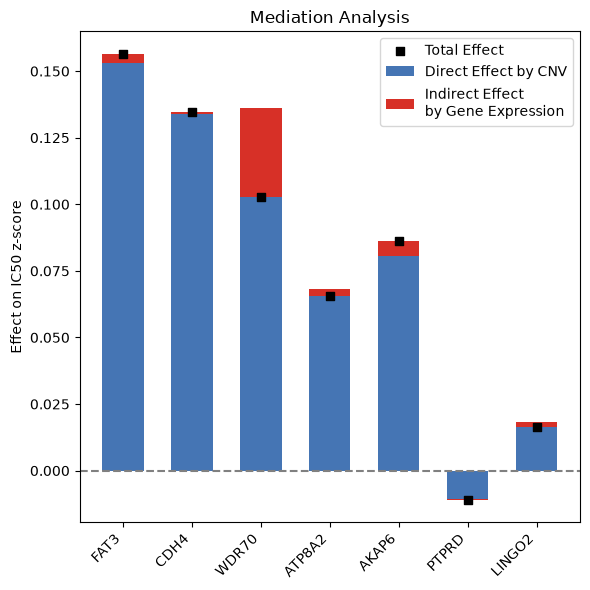

In [83]:
# 7. ----------------- 可视化（同前）-----------------
# df_plot = df_med[df_med['significant']].copy()
df_plot = df_med.head(7)
if df_plot.empty:
    print("无显著中介效应；显示前5个。")
    df_plot = df_med.head(5)

fig, ax = plt.subplots(figsize=(6, 6))
ind = np.arange(len(df_plot))
ax.bar(ind, df_plot['direct_effect_c_prime'], 0.6, label='Direct Effect by CNV', color='#4575b4')
ax.bar(ind, df_plot['indirect_effect_ab'], 0.6, bottom=df_plot['direct_effect_c_prime'],
       label='Indirect Effect\nby Gene Expression', color='#d73027')
ax.scatter(ind, df_plot['total_effect_c'], color='black', marker='s', s=40, label='Total Effect')
ax.set_xticks(ind)
ax.set_xticklabels(df_plot['gene'], rotation=45, ha='right')
ax.set_ylabel('Effect on IC50 z-score')
ax.set_title('Mediation Analysis')
ax.legend()
ax.axhline(0, color='grey', linestyle='--')
plt.tight_layout()
plt.savefig('./LightGBM2.0/mediation_analysis.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [49]:
df_analysis

,cell_id,IC50_zscore,FAT3_CNV,CDH4_CNV,WDR70_CNV,ATP8A2_CNV,AKAP6_CNV,PTPRD_CNV,LINGO2_CNV,DCC_CNV,...,DCC,MSRA,CEP85L,TRAPPC9,BBS9,KAZN,SLC44A5,ULK4,CDKAL1,MECOM
0,SIDM00003,-0.163038,3.0,5.0,3.0,3.0,2.0,3.0,3.0,2.0,...,0.0000,4.4289,1.5850,3.0144,3.3277,4.9388,0.0144,3.3161,3.7634,0.0426
1,SIDM00023,0.567856,4.0,6.0,6.0,4.0,4.0,2.0,3.0,2.0,...,0.0566,1.6323,1.2265,4.2265,3.2585,4.0179,3.5862,2.0566,2.6112,4.6747
2,SIDM00040,-0.001298,3.0,3.0,5.0,2.0,3.0,3.0,3.0,2.0,...,0.0000,6.2902,0.6781,4.0968,0.7991,0.7824,0.8074,1.5993,2.5680,0.4542
3,SIDM00041,-0.522523,4.0,3.0,4.0,4.0,4.0,5.0,3.0,3.0,...,0.0566,4.1875,2.6299,4.1611,3.1010,2.7677,2.0072,2.0875,3.4555,3.5484
4,SIDM00042,0.135437,5.0,7.0,6.0,7.0,6.0,4.0,4.0,0.0,...,0.0000,2.8679,0.9928,3.7495,2.0144,2.2265,2.3334,1.4436,3.4803,2.6182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,SIDM01247,-0.545375,2.0,3.0,2.0,1.0,2.0,2.0,2.0,2.0,...,0.0000,0.3674,3.2001,2.7049,3.0426,0.3674,0.0704,1.9635,3.8709,0.1763
940,SIDM01248,-0.148433,4.0,5.0,3.0,3.0,4.0,2.0,2.0,2.0,...,3.2357,3.7506,2.1010,4.1102,3.9146,1.5656,2.2141,2.0461,3.6439,1.9184
941,SIDM01251,-0.854412,2.0,4.0,3.0,2.0,2.0,0.0,2.0,5.0,...,0.0000,2.6369,3.9598,4.9882,1.7824,4.7560,1.2016,1.9672,3.9588,0.4751
942,SIDM01259,-0.972654,2.0,2.0,2.0,3.0,2.0,1.0,1.0,2.0,...,0.0000,0.8718,3.6565,4.7798,4.1085,1.1110,4.5692,2.4222,4.4363,0.0144
